# Simple Autoencoder
- Experimentation using : https://medium.com/analytics-vidhya/image-denoising-using-deep-learning-dc2b19a3fd54
- Un-Normalized Inputs (as instructed by sir)

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import json

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.style.use('dark_background')
print("Pytorch version :",torch.__version__)
print("Numpy version :",np.__version__)
print("Using device : ",device)

Pytorch version : 2.7.0+cu126
Numpy version : 2.3.4
Using device :  cuda


In [7]:
# Paths
NOTEBOOK_DIR = Path().resolve()
BASE_DIR = NOTEBOOK_DIR.parents[2]
DATASET_DIR = BASE_DIR / "data" / "1-all-noise-no-cf"

MODEL_OUTPUT_DIR = BASE_DIR / "models" / "3-simple-autoencoder" 
MODEL_OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

INPUT_DIR  = DATASET_DIR / "input"
TARGET_DIR = DATASET_DIR / "target"
HEIGHT , WIDTH = 256 , 256
IMAGE_SIZE = (HEIGHT , WIDTH)
import sys
sys.path.append(str(BASE_DIR))
import helper

for name, directory in [("Input", INPUT_DIR), ("Target", TARGET_DIR)]:
    if directory.is_dir():
        files = list(directory.glob('*'))
        print(f"✅ {name} Directory: {'Contains ' + str(len(files)) + ' files.' if files else 'Empty.'}")
    else:
        print(f"❌ {name} Directory NOT found at: {directory}")

✅ Input Directory: Contains 20000 files.
✅ Target Directory: Contains 20000 files.


In [3]:
class InterferogramDataset(Dataset):
    """Simple segmentation dataset for image-mask pairs"""
    
    def __init__(self, image_dir, mask_dir, transform=None, img_size=(512,512)):
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.transform = transform
        self.img_size = img_size
        
        # Get all image files
        valid_exts = {".jpg", ".jpeg", ".png"}
        self.images = sorted([f for f in self.image_dir.iterdir() if f.suffix.lower() in valid_exts])
        self.masks = sorted([f for f in self.mask_dir.iterdir() if f.suffix.lower() in valid_exts])
        
        assert len(self.images) == len(self.masks), "Images and masks count mismatch!"
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        # Load image and mask
        img = Image.open(self.images[idx]).convert('L')
        mask = Image.open(self.masks[idx]).convert('L')  # Grayscale
        
        # Resize
        img = img.resize(self.img_size, Image.NEAREST)
        mask = mask.resize(self.img_size, Image.NEAREST)
        
        # Convert to numpy - UNNORMALISED
        img = np.array(img).astype(np.float32) /255
        mask = np.array(mask).astype(np.float32) /255
        
        # To tensor (C, H, W)
        img = torch.from_numpy(img).unsqueeze(0)
        mask = torch.from_numpy(mask).unsqueeze(0)  # Add channel dim
        
        return img, mask

In [4]:
# Create datasets
train_dataset = InterferogramDataset(INPUT_DIR, TARGET_DIR, img_size=IMAGE_SIZE)
BATCH_SIZE = 16
# Split into train/val (80/20)
train_size = int(0.65 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])
# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")


Train samples: 13000, Val samples: 7000


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AutoEncoder(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base_filters=2):
        super().__init__()

        # Encoder
        self.enc1 = nn.Conv2d(in_channels, base_filters, kernel_size=3, padding=1)
        self.enc2 = nn.Conv2d(base_filters, base_filters * 2, kernel_size=3, padding=1)
        self.enc3 = nn.Conv2d(base_filters * 2, base_filters * 4, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        # Decoder
        self.dec1 = nn.ConvTranspose2d(base_filters * 4, base_filters * 4, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.dec2 = nn.ConvTranspose2d(base_filters * 4, base_filters * 2, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.dec3 = nn.ConvTranspose2d(base_filters * 2, base_filters, kernel_size=3, stride=2, padding=1, output_padding=1)

        self.final = nn.Conv2d(base_filters, out_channels, kernel_size=3, padding=1)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        # Encoder
        x = F.relu(self.enc1(x))
        x = self.pool(x)
        x = F.relu(self.enc2(x))
        x = self.pool(x)

        x = F.relu(self.enc3(x))
        x = self.pool(x)

        # Decoder
        x = F.relu(self.dec1(x))
        x = F.relu(self.dec2(x))
        x = F.relu(self.dec3(x))

        # x = torch.sigmoid(self.final(x))
        x = self.final(x)
        return x


In [6]:
class DiceLoss(nn.Module):
    """Dice Loss for segmentation"""
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
        
    def forward(self, pred, target):
        pred = pred.contiguous().view(-1)
        target = target.contiguous().view(-1)
        
        intersection = (pred * target).sum()
        dice = (2. * intersection + self.smooth) / (pred.sum() + target.sum() + self.smooth)
        
        return 1 - dice

class CombinedLoss(nn.Module):
    """Combines Dice Loss and BCE"""
    def __init__(self, dice_weight=0.5, bce_weight=0.5):
        super().__init__()
        self.dice = DiceLoss()
        self.bce = nn.BCELoss()
        self.dice_weight = dice_weight
        self.bce_weight = bce_weight
        
    def forward(self, pred, target):
        return self.dice_weight * self.dice(pred, target) + self.bce_weight * self.bce(pred, target)
    
def calculate_iou(pred, target, threshold=0.5):
    """Calculate IoU metric"""
    pred = (pred > threshold).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.item()


In [8]:
model = AutoEncoder(in_channels=1, out_channels=1, base_filters=2)
model = model.to(device)
x = torch.randn(1, 1, 256, 256).to(device)
y = model(x)
print(y.shape)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
helper.inspect_model(
    model, 
    input_size=(1,1,HEIGHT,WIDTH),
    criterion=criterion,
    optimizer=optimizer,
    model_name="U-Net-Lite with Residual Connections"
)

torch.Size([1, 1, 256, 256])


────────────────────────────────────── U-Net-Lite with Residual Connections ───────────────────────────────────────

Architecture Summary:

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
AutoEncoder                              [1, 1, 256, 256]          [1, 1, 256, 256]          --
├─Conv2d: 1-1                            [1, 1, 256, 256]          [1, 2, 256, 256]          20
├─MaxPool2d: 1-2                         [1, 2, 256, 256]          [1, 2, 128, 128]          --
├─Conv2d: 1-3                            [1, 2, 128, 128]          [1, 4, 128, 128]          76
├─MaxPool2d: 1-4                         [1, 4, 128, 128]          [1, 4, 64, 64]            --
├─Conv2d: 1-5                            [1, 4, 64, 64]            [1, 8, 64, 64]            296
├─MaxPool2d: 1-6                         [1, 8, 64, 64]            [1, 8, 32, 32]            --
├─ConvTranspose2d: 1-7                   [1, 8, 32, 32]            [1, 8, 64, 64]            584
├─ConvTranspose2d: 1-8                   [1, 8, 64, 64]            [1, 4, 128, 128]          292
├─ConvTranspose2d: 1-9          

MACs and Parameters (ptflops):

╷             
  Metric               │      Value  
 ══════════════════════╪════════════ 
  Total Parameters     │      1,361  
  Trainable Parameters │      1,361  
  Optimizer Params     │      1,361  
  Model Size (MB)      │      0.005  
  MACs                 │ 17.96 MMac  
  FLOPs (approx)       │ 17.96 MMac  
  Loss Function        │    MSELoss  
  Optimizer            │       Adam  
                       ╵

{'total_params': 1361,
 'trainable_params': 1361,
 'optimizer_params': 1361,
 'model_size_mb': 0.005191802978515625,
 'MACs': '17.96 MMac',
 'FLOPs': '17.96 MMac',
 'criterion': 'MSELoss',
 'optimizer': 'Adam'}

In [11]:
model.eval()  # VERY IMPORTANT
torch.onnx.export(
    model,
    x,
    "model.onnx",
    export_params=True,
    opset_version=17,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input": {0: "batch_size"},
        "output": {0: "batch_size"},
    }
)
import netron
netron.start("model.onnx")

Serving 'model.onnx' at http://localhost:8081


('localhost', 8081)

In [17]:
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure

psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    psnr_metric.reset()
    ssim_metric.reset()

    for imgs, masks in tqdm(loader, desc="Training", leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        # Metrics (detach gradients)
        psnr_metric.update(outputs.detach(), masks)
        ssim_metric.update(outputs.detach(), masks)
    n = len(loader)
    avg_loss = total_loss / n
    avg_psnr = psnr_metric.compute().item()
    avg_ssim = ssim_metric.compute().item()
    return avg_loss, avg_psnr, avg_ssim

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    psnr_metric.reset()
    ssim_metric.reset()

    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc="Validation", leave=False):
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, masks)
            total_loss += loss.item()
            psnr_metric.update(outputs, masks)
            ssim_metric.update(outputs, masks)
    n = len(loader)
    avg_loss = total_loss / n
    avg_psnr = psnr_metric.compute().item()
    avg_ssim = ssim_metric.compute().item()
    return avg_loss, avg_psnr, avg_ssim


In [14]:
mlflow_enabled = True
if mlflow_enabled:
    from loguru import logger
    import mlflow
    mlflow.end_run()
    mlflow.pytorch.autolog()
    run_name = "1-autoencoder_baseline"
    experiment_name =  "AnalyticsVidhya"
    tracking_uri =  "http://localhost:5000"
    mlflow.set_tracking_uri(tracking_uri)
    mlflow.set_experiment(experiment_name)
    mlflow.start_run(run_name=run_name,log_system_metrics=True)
    logger.info(f"MLflow run started | experiment={experiment_name} | run_name={run_name}")

2026/01/03 19:20:16 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...


🏃 View run autoencoder_baseline at: http://localhost:5000/#/experiments/224237832703972600/runs/dc107d186b344cd196d4c80b81aea582
🧪 View experiment at: http://localhost:5000/#/experiments/224237832703972600


2026/01/03 19:20:17 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
2026/01/03 19:20:18 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/01/03 19:20:18 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026-01-03 19:20:18.060 | INFO     | __main__:<module>:13 - MLflow run started | experiment=AnalyticsVidhya | run_name=1-autoencoder_baseline


In [15]:
history = {
    'train_loss': [] , 'val_loss': []
}
best_val_loss = float('inf')

In [18]:
# Training with detailed loss tracking
epochs = 25

for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")

    train_loss, train_psnr, train_ssim = train_epoch(model, train_loader,criterion, optimizer, device)
    val_loss, val_psnr, val_ssim  = validate(model, val_loader ,criterion, device)
    # Store history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    scheduler.step(val_loss)
    print(f"Train | Loss: {train_loss:.4f}, PSNR: {train_psnr:.2f}, SSIM: {train_ssim:.4f}")
    print(f"Val   | Loss: {val_loss:.4f}, PSNR: {val_psnr:.2f}, SSIM: {val_ssim:.4f}")
    # print(f"Loss : {'Train':<3} = {train_loss:.4f} | {'Val':<3} = {val_loss:.4f}")
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_OUTPUT_DIR /  f"best_model.pth")
        print(f" Best model saved at epoch {epoch}")

Epoch 1/25


Train | Loss: 0.0942, PSNR: 10.26, SSIM: 0.0603
Val   | Loss: 0.0338, PSNR: 14.71, SSIM: 0.0936
 Best model saved at epoch 0
Epoch 2/25


Train | Loss: 0.0206, PSNR: 16.86, SSIM: 0.1761
Val   | Loss: 0.0130, PSNR: 18.86, SSIM: 0.2612
 Best model saved at epoch 1
Epoch 3/25


Train | Loss: 0.0111, PSNR: 19.54, SSIM: 0.3185
Val   | Loss: 0.0096, PSNR: 20.17, SSIM: 0.3683
 Best model saved at epoch 2
Epoch 4/25


Train | Loss: 0.0089, PSNR: 20.52, SSIM: 0.4120
Val   | Loss: 0.0081, PSNR: 20.93, SSIM: 0.4529
 Best model saved at epoch 3
Epoch 5/25


...

Train | Loss: 0.0040, PSNR: 23.99, SSIM: 0.7408
Val   | Loss: 0.0038, PSNR: 24.17, SSIM: 0.7414
 Best model saved at epoch 20
Epoch 22/25


Train | Loss: 0.0039, PSNR: 24.11, SSIM: 0.7424
Val   | Loss: 0.0037, PSNR: 24.26, SSIM: 0.7428
 Best model saved at epoch 21
Epoch 23/25


Train | Loss: 0.0038, PSNR: 24.21, SSIM: 0.7433
Val   | Loss: 0.0037, PSNR: 24.36, SSIM: 0.7427
 Best model saved at epoch 22
Epoch 24/25


Train | Loss: 0.0037, PSNR: 24.30, SSIM: 0.7436
Val   | Loss: 0.0036, PSNR: 24.46, SSIM: 0.7436
 Best model saved at epoch 23
Epoch 25/25


Train | Loss: 0.0036, PSNR: 24.40, SSIM: 0.7442
Val   | Loss: 0.0035, PSNR: 24.53, SSIM: 0.7461
 Best model saved at epoch 24


In [19]:
print("TRAINING SUMMARY")
print(f"Best Validation Loss:      {min(history['val_loss']):.4f} (Epoch {np.argmin(history['val_loss'])+1})")

TRAINING SUMMARY
Best Validation Loss:      0.0035 (Epoch 25)


In [20]:
# Save final model in multiple formats
torch.save(model.state_dict(), MODEL_OUTPUT_DIR / "final_model_state_dict.pth")
torch.save(model, MODEL_OUTPUT_DIR / "final_model_complete.pth")
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history
}, MODEL_OUTPUT_DIR / "checkpoint.pth")
print("\n✓ All models saved!")


✓ All models saved!


In [35]:
i=1

Original pred shape: (1, 1, 256, 256)
After squeeze shape: (256, 256)



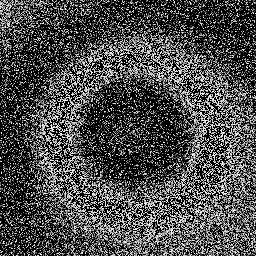
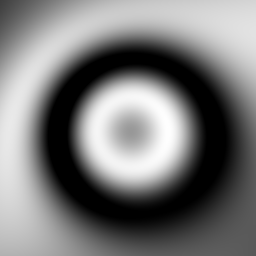
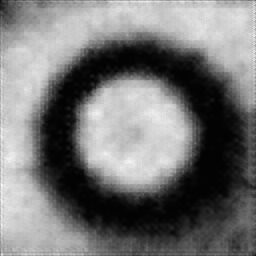

In [36]:
# Load best model
model.load_state_dict(torch.load(MODEL_OUTPUT_DIR / "best_model.pth"))
model.eval()
# Get random images
input_path, target_path = helper.get_images_from_dirs([INPUT_DIR, TARGET_DIR])
# Load and preprocess
img_pil = Image.open(input_path).convert('L')
mask_pil = Image.open(target_path).convert('L')

img_resized = img_pil.resize((HEIGHT, WIDTH))
img_tensor = torch.from_numpy(np.array(img_resized).astype(np.float32) / 255.0).unsqueeze(0).to(device)
img_tensor = img_tensor.unsqueeze(0)  # This makes it (1, 1, H, W)

# Predict
with torch.no_grad():
    pred = model(img_tensor).cpu().numpy()

print(f"Original pred shape: {pred.shape}")
pred = pred.squeeze() # This converts (1, 1, 256, 256) -> (256, 256)
print(f"After squeeze shape: {pred.shape}")

# Convert for visualization
img_np = np.array(img_resized)
mask_np = np.array(mask_pil.resize((HEIGHT, WIDTH))) / 255.0

# Display using helper
helper.show_grid({
    'Noise Mask': (img_np * 255).astype(np.uint8),
    'Target Mask': (mask_np * 255).astype(np.uint8),
    'Predicted Mask': (pred * 255).astype(np.uint8),  # Now this is 2D
}, grid="row", width=1200)

In [37]:
from pathlib import Path
import cv2
artifact_dir = Path("mlflow_artifacts")
artifact_dir.mkdir(exist_ok=True)
i+=1
comparison = np.concatenate(
    [
        (img_np * 255).astype(np.uint8),
        (mask_np * 255).astype(np.uint8),
        (pred * 255).astype(np.uint8),
    ],
    axis=1
)

comparison_path = artifact_dir / f"{i}_comparison.png"
cv2.imwrite(str(comparison_path), comparison)
mlflow.log_artifact(str(comparison_path), artifact_path="predictions")

In [38]:
mlflow.end_run()

2026/01/03 20:08:22 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...


🏃 View run 1-autoencoder_baseline at: http://localhost:5000/#/experiments/224237832703972600/runs/4c750d8b858844f390e414762a617f0a
🧪 View experiment at: http://localhost:5000/#/experiments/224237832703972600


2026/01/03 20:08:22 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
